In [2]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from numba import njit, prange
from matplotlib.animation import FuncAnimation,FFMpegWriter, PillowWriter
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
import time
import pandas as pd
from copy import deepcopy
import seaborn as sns
from numba import set_num_threads
from itertools import product
from tqdm import tqdm
from collections import defaultdict
import copy
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker  # Para la barra de color

# Define un colormap de blanco a rojo
blanco_a_rojo = LinearSegmentedColormap.from_list("white_red", ["white", "red"])

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    # No uses font.weight aquí: no afecta cuando usas LaTeX
})

set_num_threads(14)  # Reemplaza N con el número de núcleos que quieres usar

---
---
## 🔁 Simulación en múltiples resoluciones

Se simulan los campos para distintas resoluciones (`25x25` hasta `800x800`). Los resultados se guardan en `sim_dif_resl/{res}.pkl`.


# Funcion general de simulacion

In [3]:
@njit(parallel=True, fastmath=True)
def actualizar_campos(presion_adversa, u_old, v_old, p_old, T_old, u_star, v_star, p_star, T_star,
                      Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny):
    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_u_x = u_old[i, j] * (u_old[i, j + 1] - u_old[i, j - 1]) / (2 * dx_star)
            conv_u_y = v_old[i, j] * (u_old[i + 1, j] - u_old[i - 1, j]) / (2 * dy_star)
            diff_u_x = (u_old[i, j + 1] - 2 * u_old[i, j] + u_old[i, j - 1]) / dx_star**2
            diff_u_y = (u_old[i + 1, j] - 2 * u_old[i, j] + u_old[i - 1, j]) / dy_star**2
            u_star[i, j] += dt_star * (-conv_u_x - conv_u_y + (1 / Re) * (diff_u_x + diff_u_y))

            conv_v_x = u_old[i, j] * (v_old[i, j + 1] - v_old[i, j - 1]) / (2 * dx_star)
            conv_v_y = v_old[i, j] * (v_old[i + 1, j] - v_old[i - 1, j]) / (2 * dy_star)
            diff_v_x = (v_old[i, j + 1] - 2 * v_old[i, j] + v_old[i, j - 1]) / dx_star**2
            diff_v_y = (v_old[i + 1, j] - 2 * v_old[i, j] + v_old[i - 1, j]) / dy_star**2
            grad_p_y = (p_old[i + 1, j] - p_old[i - 1, j]) / (2 * dy_star)
            v_star[i, j] += dt_star * (-conv_v_x - conv_v_y - Eu * grad_p_y + (1 / Re) * (diff_v_x + diff_v_y))

    for _ in range(20):
        for i in prange(1, ny - 1):
            for j in prange(1, nx - 1):
                div = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star) + \
                      (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
                p_star[i, j] = 0.25 * (p_old[i + 1, j] + p_old[i - 1, j] +
                                       p_old[i, j + 1] + p_old[i, j - 1] -
                                       (dx_star * dy_star) / (2 * (dx_star**2 + dy_star**2)) * div)
    
    # Gradiente de presión controlado
    for j in prange(nx):
        x = j * dx_star
        for i in prange(ny):
            if x <= 0.3:
                p_star[i, j] += 0.01  # presión constante en entrada
            else:
                p_star[i, j] += presion_adversa * (x - 0.3)


    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            u_star[i, j] -= dt_star * Eu * (p_star[i, j + 1] - p_star[i, j - 1]) / (2 * dx_star)
            v_star[i, j] -= dt_star * Eu * (p_star[i + 1, j] - p_star[i - 1, j]) / (2 * dy_star)

    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_T_x = u_star[i, j] * (T_old[i, j + 1] - T_old[i, j - 1]) / (2 * dx_star)
            conv_T_y = v_star[i, j] * (T_old[i + 1, j] - T_old[i - 1, j]) / (2 * dy_star)
            diff_T_x = (T_old[i, j + 1] - 2 * T_old[i, j] + T_old[i, j - 1]) / dx_star**2
            diff_T_y = (T_old[i + 1, j] - 2 * T_old[i, j] + T_old[i - 1, j]) / dy_star**2
            Sxx = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star)
            Syy = (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
            Sxy = 0.5 * ((u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star) +
                         (v_star[i, j + 1] - v_star[i, j - 1]) / (2 * dx_star))
            viscous_heating = (Ec / Re) * (2 * (Sxx**2 + Syy**2) + 4 * Sxy**2)
            T_star[i, j] += dt_star * (-conv_T_x - conv_T_y +
                                       (1 / (Re * Pr)) * (diff_T_x + diff_T_y) +
                                       viscous_heating)

    tau = np.zeros((ny, nx))
    for i in prange(1, ny - 1):
        for j in prange(nx):
            tau[i, j] = (u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star)

# Condiciones de frontera
    v_star[0, :] = 0
    v_star[-1, :] = 0
    u_star[0, :] = -0.5
    u_star[-1, :] = 1.0
    u_star[:, -1] = u_star[:, -2]
    p_star[:, 0] = p_star[:, 1]
    p_star[:, -1] = p_star[:, -2]
    p_star[0, :] = p_star[1, :]
    p_star[-1, :] = p_star[-2, :]

    return u_star, v_star, p_star, T_star, tau

def run_simulacion_general(nx=25, ny=25, presion_adversa=0.3,
                           observaciones_dict=None,
                           metodo_asimilacion=None,
                           variables_asimilar=['T'],
                           metodo_kwargs={},
                           N_FRAMES=300):
    """
    Simulación general que permite asimilación de datos opcional (sin guardado en disco).

    Parámetros:
    -----------
    nx, ny : int
        Resolución espacial.
    presion_adversa : float
        Presión aplicada en la entrada.
    observaciones_dict : dict
        Diccionario {timestep: observaciones}.
    metodo_asimilacion : function or None
        Función que aplica asimilación (e.g., aplicar_nudging).
    variables_asimilar : list of str
        Variables a asimilar (e.g., ['T', 'p']).
    metodo_kwargs : dict
        Parámetros adicionales para el método de asimilación.
    N_FRAMES : int
        Número de frames a guardar (espaciados uniformemente).

    Retorna:
    --------
    dict con históricos y parámetros.
    """

    # --- Parámetros físicos y temporales ---
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    save_interval = max(1, nt // N_FRAMES)
    save_times = set(range(0, nt, save_interval))
    save_times.add(nt - 1)

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # --- Condiciones iniciales ---
    u0, up = 1.0, -0.5
    T0_star, T1_star = 0.0, 0.0
    u_star = np.ones((ny, nx)) * u0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.ones((ny, nx)) * T1_star
    u_star[0, :] = up
    u_star[-1, :] = u0
    T_star[0, :] = T0_star
    T_star[-1, :] = T1_star

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_assim_time = 0.0

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
        u_star, v_star, p_star, T_star, tau = actualizar_campos(
            presion_adversa, u_old, v_old, p_old, T_old,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
        )

        # Asimilación si corresponde
        if observaciones_dict and n in observaciones_dict and metodo_asimilacion:
            t0 = time.time()
            obs_t = observaciones_dict[n]
            for var in variables_asimilar:
                if var in obs_t:
                    campo = {'T': T_star, 'p': p_star, 'tau': tau}[var]
                    campo_asim = metodo_asimilacion(
                        campo_modelo=campo,
                        observaciones=obs_t,
                        variable=var,
                        nx=nx, ny=ny,
                        **metodo_kwargs
                    )
                    if var == 'T': T_star = campo_asim
                    elif var == 'p': p_star = campo_asim
                    elif var == 'tau': tau = campo_asim
            total_assim_time += time.time() - t0

        # Guardar en memoria
        if n in save_times:
            u_hist.append(u_star.copy())
            v_hist.append(v_star.copy())
            p_hist.append(p_star.copy())
            T_hist.append(T_star.copy())
            tau_hist.append(tau.copy())

    print("\n✅ Simulación finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "metodo_asimilacion": metodo_asimilacion.__name__ if metodo_asimilacion else None,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }



In [4]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:

    # --- Asegura que existe la carpeta de salida ---
    os.makedirs("sim_dif_resl", exist_ok=True)

    # --- Lista de resoluciones (lado x = lado y) ---
    resoluciones = [25, 50, 100, 200, 400, 800]

    # --- Simulación para cada resolución ---
    for res in tqdm(resoluciones, desc="Generando simulaciones"):
        print(f"\n🔧 Resolución: {res}x{res}")

        sim_data = run_simulacion_general(
            nx=res, ny=res,
            metodo_asimilacion=None,
            N_FRAMES=300,
            presion_adversa=0.3
        )

        ruta_salida = f"sim_dif_resl/{res}.pkl"
        with open(ruta_salida, "wb") as f:
            pickle.dump(sim_data, f)

        print(f"✅ Guardado: {ruta_salida}")



## 📈 Estudio de Convergencia

In [5]:
def calcular_parametros(sim_data):
    """
    Calcula parámetros de separación, burbuja de recirculación y grosor de  capa límite
    a partir de los datos de simulación.
    Parámetros:
    - sim_data: diccionario con datos de simulación que contiene:
        - 'u_history': historial de velocidades (array 2D)
        - 'X_star': coordenadas X (array 2D)
        - 'Y_star': coordenadas Y (array 2D)
    Retorna:
    - x_sep: posición de separación (float)
    - bubble: tamaño de la burbuja de recirculación (float)
    - delta: grosor de la capa límite (float)
    """
    u_hist = sim_data['u_history']
    X = sim_data['X_star']
    Y = sim_data['Y_star']

    final_u = u_hist[-1]

    # Tomamos la línea más baja (y≈0)
    y_line_idx = 1  # la segunda fila desde abajo
    u_bottom = final_u[y_line_idx, :]
    x_vals = X[y_line_idx, :]

    # Buscar cambio de signo de positivo a negativo (indica separación)
    signo = np.sign(u_bottom)
    cambios = np.where(np.diff(signo) < 0)[0]

    x_sep = None
    if len(cambios) > 0:
        x_sep = x_vals[cambios[0]]
    
    # Buscar burbuja de recirculación (donde u < 0)
    indices_negativos = np.where(u_bottom < 0)[0]
    bubble = None
    if len(indices_negativos) > 1:
        bubble = x_vals[indices_negativos[-1]] - x_vals[indices_negativos[0]]

    # Calcular delta como grosor de la capa límite al final
    y_vals = Y[:, -1]  # columna más a la derecha
    u_profile = final_u[:, -1]
    u_inf = np.max(u_profile)
    delta = None
    for i in range(len(u_profile)):
        if u_profile[i] >= 0.99 * u_inf:
            delta = y_vals[i]
            break

    return x_sep, bubble, delta



In [6]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:

    # Asegúrate de que calcular_parametros está definida antes de este bloque

    # --- Configuración ---
    carpeta = 'sim_dif_res'
    resoluciones = [25, 50, 100, 200, 400, 800]

    # --- Resultados del análisis ---
    resultados = []

    def cargar_datos(resolucion):
        nombre_archivo = os.path.join(carpeta, f"{resolucion}.pkl")
        with open(nombre_archivo, 'rb') as f:
            data = pickle.load(f)
        return data

    # --- Carga y análisis de datos ---
    for res in resoluciones:
        try:
            datos = cargar_datos(res)
            x_sep, bubble, delta = calcular_parametros(datos)
            resultados.append({
                'resolucion': res,
                'x_sep': x_sep,
                'bubble_size': bubble,
                'delta': delta
            })
        except Exception as e:
            print(f"❌ Error al procesar resolución {res}: {e}")

    '''# --- Mostrar resultados individuales ---
    for r in resultados:
        print(f"{r['resolucion']}x{r['resolucion']} -> "
            f"x_sep: {r['x_sep']}, bubble: {r['bubble_size']}, delta: {r['delta']}")'''

    # --- Variables para análisis de convergencia ---
    resoluciones_validas = [r['resolucion'] for r in resultados if r['delta'] is not None]
    x_sep_vals = [r['x_sep'] for r in resultados if r['x_sep'] is not None]
    bubble_vals = [r['bubble_size'] for r in resultados if r['bubble_size'] is not None]
    delta_vals = [r['delta'] for r in resultados if r['delta'] is not None]


In [7]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:
    # Datos obtenidos
    resoluciones = [25, 50, 100, 200, 400, 800]

    # Función para calcular orden de convergencia
    def orden_convergencia(f1, f2, f3, r):
        return np.log((f3 - f2) / (f2 - f1)) / np.log(r)

    # Calcular orden de convergencia (solo con los 3 valores más refinados)
    r = 2
    p_xsep = orden_convergencia(x_sep_vals[2], x_sep_vals[3], x_sep_vals[4], r)
    p_bubble = orden_convergencia(bubble_vals[2], bubble_vals[3], bubble_vals[4], r)

    # delta es casi constante; su orden no es confiable
    delta_casi_constante = all(np.isclose(d, 1.0) for d in delta_vals[:-1])
    p_delta = None if delta_casi_constante else orden_convergencia(delta_vals[2], delta_vals[3], delta_vals[4], r)

    # Gráfica para x_sep
    plt.figure()
    plt.plot(resoluciones, x_sep_vals, marker='o')
    plt.title(f'Location Separation vs Resolution', fontsize=20)
    plt.xlabel('Resolution', fontsize=20)
    plt.ylabel(r'$x_{sep}$', fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid()

    '''# Gráfica para tamaño de burbuja
    plt.figure()
    plt.plot(resoluciones, bubble_vals, marker='s')
    plt.title(f'bubble size vs Resolution (p ≈ {p_bubble:.2f})')
    plt.xlabel('Resolution')
    plt.ylabel('Tamaño de burbuja')
    plt.grid()

    # Gráfica para delta
    plt.figure()
    plt.plot(resoluciones, delta_vals, marker='^')
    title = 'boundary layer thickness vs Resolution'
    if p_delta is not None:
        title += f' (p ≈ {p_delta:.2f})'
    plt.title(title)
    plt.xlabel('Resolution')
    plt.ylabel('δ')
    plt.grid()'''

    plt.show()


In [8]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:
    # --- Valores de entrada ---
    resoluciones = [25, 50, 100, 200, 400, 800]  # Resoluciones simuladas

    # --- Valores de x_sep previamente calculados ---
    # Asegúrate de que x_sep_vals esté definido antes de este bloque
    # Por ejemplo:
    # x_sep_vals = [0.32, 0.34, 0.36, 0.37, 0.375, 0.376]

    # --- Valor de referencia (mayor resolución) ---
    x_sep_ref = x_sep_vals[-1]

    # --- Cálculo del valor relativo respecto al de referencia ---
    x_sep_relativo = [val / x_sep_ref for val in x_sep_vals[:-1]]  # excluye el último (800x800)

    # --- Gráfica ---
    plt.figure(figsize=(8, 5))
    plt.plot(resoluciones[:-1], x_sep_relativo, marker='o', linewidth=2, label=r'Relative value $x_{\mathrm{sep}} / x_{\mathrm{sep,ref}}$')
    plt.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='Reference (800×800)')
    plt.title("Relative value of separation point vs resolution", fontsize=20)
    plt.xlabel("Resolution", fontsize=20)
    plt.ylabel("Relative Value", fontsize=20)
    plt.grid(True, which="both", ls="--")
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(fontsize=20)
    plt.tight_layout()
    plt.show()


# Normalizacion de los datos

In [9]:
def normalizar_simulaciones(carpeta_entrada="sim_dif_res", carpeta_salida="sim_normal"):
    os.makedirs(carpeta_salida, exist_ok=True)

    # --- 1. Buscar archivos .pkl ---
    archivos = [f for f in os.listdir(carpeta_entrada) if f.endswith(".pkl")]
    if not archivos:
        print("❌ No se encontraron archivos .pkl en la carpeta de entrada.")
        return

    print(f"🔍 Archivos encontrados: {archivos}")

    # --- 2. Extraer valores globales ---
    all_vals = {"T": [], "p": [], "tau": []}
    sims = {}

    for archivo in archivos:
        with open(os.path.join(carpeta_entrada, archivo), "rb") as f:
            sim = pickle.load(f)
            sims[archivo] = sim

            for var in ["T", "p", "tau"]:
                hist = sim.get(f"{var}_history", [])
                for frame in hist:
                    all_vals[var].extend(frame.ravel())

    # --- 3. Calcular el valor absoluto máximo global ---
    norm_info = {}
    for var in ["T", "p", "tau"]:
        arr = np.array(all_vals[var])
        max_abs = np.max(np.abs(arr))
        if max_abs == 0:
            print(f"⚠️ {var}: Todos los valores son cero. Se omite normalización.")
            norm_info[var] = None
        else:
            norm_info[var] = max_abs
            print(f"🔧 Normalización {var}: max |valor| = {max_abs:.6f}")

    # --- 4. Aplicar normalización y guardar ---
    for archivo, sim in sims.items():
        sim_norm = copy.deepcopy(sim)
        for var in ["T", "p", "tau"]:
            if norm_info[var] is not None:
                max_abs = norm_info[var]
                sim_norm[f"{var}_history"] = [
                    f / max_abs for f in sim[f"{var}_history"]
                ]
        salida_path = os.path.join(carpeta_salida, archivo)
        with open(salida_path, "wb") as f:
            pickle.dump(sim_norm, f)
        print(f"✅ Guardado normalizado: {salida_path}")

    print("🎯 Todas las simulaciones fueron normalizadas y guardadas (preservando signo).")


In [10]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:
    # Ejecutar la normalización global sobre los datos en sim_dif_res
    normalizar_simulaciones(
        carpeta_entrada="sim_dif_res",
        carpeta_salida="sim_normal"
    )

## 🧠 Asimilación de Datos

Se ejecutan distintas configuraciones de asimilación usando `nudging`, `Kalman Filter`, `EnKF`, y `4DVar`.

Los resultados se analizan calculando el `RMSE` con respecto a la referencia interpolada.


# Bin datos de 800x800 a 25x25

In [11]:
def downsample_por_bloques(frames, factor):
    frames = np.array(frames)
    n_frames, H, W = frames.shape
    h_new, w_new = H // factor, W // factor
    frames = frames[:, :h_new*factor, :w_new*factor]  # Recortar si no divisible
    frames_reducidos = frames.reshape(n_frames, h_new, factor, w_new, factor)
    return frames_reducidos.mean(axis=(2, 4))

def reducir_por_bloques_simulacion(
    archivo_origen="sim_normal/800.pkl",
    carpeta_destino="sim_normal",
    resolucion_objetivo=25
):
    factor = 800 // resolucion_objetivo
    if 800 % resolucion_objetivo != 0:
        raise ValueError("⚠️ La resolución 800 no es divisible por la resolución objetivo.")

    with open(archivo_origen, "rb") as f:
        sim = pickle.load(f)

    # Reducción por bloques para todas las variables
    sim_reducido = {
        "T_history": downsample_por_bloques(sim["T_history"], factor),
        "p_history": downsample_por_bloques(sim["p_history"], factor),
        "tau_history": downsample_por_bloques(sim["tau_history"], factor),
        "u_history": downsample_por_bloques(sim["u_history"], factor),
        "v_history": downsample_por_bloques(sim["v_history"], factor),
    }

    # Crear nuevas mallas X, Y reducidas
    x_physical = np.linspace(0, 1, resolucion_objetivo)
    y_physical = np.linspace(0, 1, resolucion_objetivo)
    X_star, Y_star = np.meshgrid(x_physical, y_physical)

    sim_reducido["X_star"] = X_star
    sim_reducido["Y_star"] = Y_star
    sim_reducido["params"] = {
        "nx": resolucion_objetivo,
        "ny": resolucion_objetivo,
        "fuente": "downsample_por_bloques_desde_800x800"
    }
    sim_reducido["descripcion"] = f"Reducción por bloques desde 800x800 a {resolucion_objetivo}x{resolucion_objetivo}"

    # Guardar
    os.makedirs(carpeta_destino, exist_ok=True)
    nombre_archivo = f"{resolucion_objetivo}_bloques.pkl"
    with open(os.path.join(carpeta_destino, nombre_archivo), "wb") as f:
        pickle.dump(sim_reducido, f)

    print(f"✅ Guardado archivo reducido por bloques en: {os.path.join(carpeta_destino, nombre_archivo)}")


In [12]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:
    reducir_por_bloques_simulacion(
        archivo_origen="sim_normal/800.pkl",
        carpeta_destino="sim_normal",
        resolucion_objetivo=25
        )


# Observaciones

In [13]:
def extraer_observaciones(
    path_pkl,
    N_sens=10,
    T_sens=5,
    ruido_std=0.0,
    seed=None
):
    """
    Extrae observaciones desde un archivo .pkl de simulación (normalizado o no).

    Parámetros:
    - path_pkl: ruta al archivo .pkl con los datos simulados/interpolados
    - N_sens: número de sensores a lo largo de x
    - T_sens: número de pasos temporales donde tomar observaciones
    - ruido_std: desviación estándar del ruido (gaussiano)
    - seed: semilla para reproducibilidad

    Retorna:
    - Lista de diccionarios con observaciones por instante
    """

    if seed is not None:
        np.random.seed(seed)

    with open(path_pkl, "rb") as f:
        datos = pickle.load(f)

    T_hist = datos["T_history"]
    p_hist = datos["p_history"]
    tau_hist = datos["tau_history"]
    Y_star = datos["Y_star"]

    nt = len(T_hist)
    nx = T_hist[0].shape[1]
    x_physical = np.linspace(0, 1, N_sens)
    x_idx = (x_physical * (nx - 1)).astype(int)
    frame_indices = np.linspace(0, nt - 1, T_sens, dtype=int)

    # Elegir fila más cercana a y = 0.001
    y_fila = Y_star[:, 0]
    y_idx = int(np.argmin(np.abs(y_fila - 0.001)))

    observaciones = []
    for t in frame_indices:
        T_line = T_hist[t][y_idx, :]
        p_line = p_hist[t][y_idx, :]
        tau_line = tau_hist[t][y_idx, :]

        obs_t = {
            "t": t,
            "x_phys": x_physical,
            "T": T_line[x_idx].copy(),
            "p": p_line[x_idx].copy(),
            "tau": tau_line[x_idx].copy()
        }

        if ruido_std > 0.0:
            obs_t["T"] += np.random.normal(0, ruido_std, size=N_sens)
            obs_t["p"] += np.random.normal(0, ruido_std, size=N_sens)
            obs_t["tau"] += np.random.normal(0, ruido_std, size=N_sens)

        observaciones.append(obs_t)

    return observaciones


# Nudging

In [14]:
def aplicar_nudging(campo_modelo, observaciones, variable, nx, ny, alpha=0.1):
    """
    Aplica el método de Nudging para corregir un campo usando observaciones puntuales en y=0.

    Parámetros:
    -----------
    campo_modelo : ndarray
        Campo actual del modelo (T, p o tau), de tamaño (ny, nx).

    observaciones : dict
        Diccionario con las observaciones en este timestep.
        Debe contener claves como 'T', 'p', 'tau' y 'x_phys'.

    variable : str
        Nombre de la variable a asimilar: 'T', 'p' o 'tau'.

    nx, ny : int
        Tamaño espacial del dominio.

    alpha : float
        Coeficiente de nudging (cuánto se ajusta hacia la observación).

    Retorna:
    --------
    ndarray con el campo corregido.
    """
    campo_corr = campo_modelo.copy()

    if variable not in observaciones or 'x_phys' not in observaciones:
        return campo_corr

    x_phys = np.array(observaciones['x_phys'])
    x_idx = (x_phys * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)  # Asumimos observaciones en y=0

    for xi, yi, obs_val in zip(x_idx, y_idx, observaciones[variable]):
        campo_corr[yi, xi] = (1 - alpha) * campo_corr[yi, xi] + alpha * obs_val

    return campo_corr


# Kalman filter

In [15]:
def aplicar_kalman_filter(campo_modelo, observaciones, variable, nx, ny,
                          sigma_obs=0.01, sigma_modelo=1e-4):
    """
    Aplica el filtro de Kalman clásico (KF) para una variable en y=0.

    Parámetros:
    -----------
    campo_modelo : np.ndarray
        Campo actual del modelo (e.g., T_star, p_star, tau).

    observaciones : dict
        Diccionario con observaciones. Debe incluir:
        - 'x_phys': posiciones físicas de los sensores
        - variable: valores observados para esa variable

    variable : str
        Nombre de la variable a asimilar ('T', 'p' o 'tau').

    nx, ny : int
        Dimensiones del dominio.

    sigma_obs : float
        Desviación estándar del ruido de observación.

    sigma_modelo : float
        Incertidumbre del modelo (ruido del sistema).

    Retorna:
    --------
    campo_actualizado : np.ndarray
        Campo corregido en base a las observaciones.
    """
    campo_actualizado = campo_modelo.copy()
    x_phys = observaciones["x_phys"]
    obs_vals = observaciones[variable]

    x_idx = (x_phys * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)  # sensores en y = 0

    # Extraer predicciones del modelo
    x_fondo = campo_modelo[y_idx, x_idx]

    # Construir matrices
    H = np.eye(len(x_idx))  # observación directa
    R = np.eye(len(x_idx)) * sigma_obs**2
    P = np.eye(len(x_idx)) * sigma_modelo**2

    # Ganancia de Kalman
    K = P @ np.linalg.inv(P + R)

    # Corrección
    x_actualizado = x_fondo + K @ (obs_vals - H @ x_fondo)

    # Insertar corrección en el campo
    for xi, yi, val in zip(x_idx, y_idx, x_actualizado):
        campo_actualizado[yi, xi] = val

    return campo_actualizado


# Ensemble Kalman filter

Necesita su propia simulacion porque se añaden varios 'hilos' de simulacion. No solo se usa un valor inicial y se simula su evolucion (teniendo en cuenta la asimilacion), sino que genera N valores iniciales y simula su evolucion simultaneamente, formando el ensemble.

In [16]:
def run_enkf(nx=25, ny=25, N_ens=10, presion_adversa=0.3,
             observaciones_dict=None,
             variables_asimilar=['T'],
             sigma_obs=0.01, sigma_modelo=1e-4,
             N_FRAMES=300, seed=None):
    """
    Simulación con Ensemble Kalman Filter (EnKF).

    Parámetros:
    -----------
    N_ens : int
        Número de miembros del ensamble.
    sigma_obs : float
        Desviación estándar del ruido de observación.
    """
    if seed is not None:
        np.random.seed(seed)

    # Parámetros del modelo
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    save_interval = max(1, nt // N_FRAMES)
    save_times = set(range(0, nt, save_interval))
    save_times.add(nt - 1)

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # Estado inicial
    def crear_estado():
        u = np.ones((ny, nx)) * 1.0
        v = np.zeros((ny, nx))
        p = np.zeros((ny, nx))
        T = np.zeros((ny, nx))
        tau = np.zeros((ny, nx))
        u[0, :] = -0.5
        u[-1, :] = 1.0
        return {'u': u, 'v': v, 'p': p, 'T': T, 'tau': tau}

    ensamble = [crear_estado() for _ in range(N_ens)]

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_assim_time = 0.0

    for n in range(nt):
        for e in range(N_ens):
            m = ensamble[e]
            u, v, p, T, tau = m['u'], m['v'], m['p'], m['T'], m['tau']
            u_new, v_new, p_new, T_new, tau_new = actualizar_campos(
                presion_adversa, u, v, p, T,
                u.copy(), v.copy(), p.copy(), T.copy(),
                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
            )
            ensamble[e] = {'u': u_new, 'v': v_new, 'p': p_new, 'T': T_new, 'tau': tau_new}

        if observaciones_dict and n in observaciones_dict:
            t0 = time.time()
            obs_t = observaciones_dict[n]

            for var in variables_asimilar:
                x_phys = obs_t["x_phys"]
                x_idx = (x_phys * (nx - 1)).astype(int)
                y_idx = np.zeros_like(x_idx)
                Y_obs = obs_t[var]

                # Actualización punto por punto (más estable)
                for i, (xi, yi) in enumerate(zip(x_idx, y_idx)):
                    valores_ens = np.array([m[var][yi, xi] for m in ensamble])
                    var_ens = np.var(valores_ens)
                    if var_ens == 0:
                        continue  # evitar división por cero

                    # Ganancia de Kalman escalar
                    K = var_ens / (var_ens + sigma_obs**2)

                    for e in range(N_ens):
                        perturb = np.random.normal(0, sigma_obs)
                        innov = (Y_obs[i] + perturb) - ensamble[e][var][yi, xi]
                        ensamble[e][var][yi, xi] += K * innov

            total_assim_time += time.time() - t0

        if n in save_times:
            u_hist.append(np.mean([m['u'] for m in ensamble], axis=0))
            v_hist.append(np.mean([m['v'] for m in ensamble], axis=0))
            p_hist.append(np.mean([m['p'] for m in ensamble], axis=0))
            T_hist.append(np.mean([m['T'] for m in ensamble], axis=0))
            tau_hist.append(np.mean([m['tau'] for m in ensamble], axis=0))

    print("\n✅ Simulación EnKF finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "N_ens": N_ens,
            "sigma_obs": sigma_obs,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }


# 4D-Var

También necesita su propia funcion de simulacion. El proceso es totalmente diferente, al tener que buscar el estado que hace minima la funcion J

In [17]:
def run_4dvar(nx=25, ny=25, presion_adversa=0.3,
                         observaciones_dict=None,
                         variables_asimilar=['T'],
                         N_FRAMES=300,
                         ventana_asimilacion=20,
                         max_iter=10,
                         alpha=0.05):
    """
    Simulación con asimilación de datos 4DVar (simplificada).

    Parámetros:
    -----------
    ventana_asimilacion : int
        Número de pasos dentro de cada ventana de optimización.
    max_iter : int
        Número de iteraciones de ajuste por ventana.
    alpha : float
        Paso de gradiente descendente.
    """

    # --- Parámetros físicos y temporales ---
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    save_interval = max(1, nt // N_FRAMES)
    save_times = set(range(0, nt, save_interval))
    save_times.add(nt - 1)

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # --- Condiciones iniciales ---
    def crear_estado_inicial():
        u = np.ones((ny, nx)) * 1.0
        v = np.zeros((ny, nx))
        p = np.zeros((ny, nx))
        T = np.zeros((ny, nx))
        tau = np.zeros((ny, nx))
        u[0, :] = -0.5
        u[-1, :] = 1.0
        return u, v, p, T, tau

    u_star, v_star, p_star, T_star, tau = crear_estado_inicial()

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_assim_time = 0.0

    n = 0
    while n < nt:
        t0 = time.time()

        # 1. Guardar estado inicial de la ventana
        u0, v0, p0, T0, _ = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy(), tau.copy()
        estados = []

        # 2. Simular hacia adelante
        for i in range(ventana_asimilacion):
            u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
            u_star, v_star, p_star, T_star, tau = actualizar_campos(
                presion_adversa, u_old, v_old, p_old, T_old,
                u_star, v_star, p_star, T_star,
                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
            )
            estados.append((u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy(), tau.copy()))

        # 3. Calcular gradiente e intentar mejorar T0 (simplificación: solo T)
        if observaciones_dict and metodo_observaciones_en_ventana(observaciones_dict, n, ventana_asimilacion):
            for _ in range(max_iter):
                T_adj = T0.copy()
                grad = np.zeros_like(T0)

                u_tmp, v_tmp, p_tmp, T_tmp = u0.copy(), v0.copy(), p0.copy(), T_adj.copy()
                for i in range(ventana_asimilacion):
                    u_tmp, v_tmp, p_tmp, T_tmp, _ = actualizar_campos(
                        presion_adversa, u_tmp.copy(), v_tmp.copy(), p_tmp.copy(), T_tmp.copy(),
                        u_tmp, v_tmp, p_tmp, T_tmp,
                        Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
                    )
                    timestep = n + i
                    if timestep in observaciones_dict:
                        obs = observaciones_dict[timestep]
                        if 'T' in obs:
                            for x_phys, val in zip(obs['x_phys'], obs['T']):
                                j = int(x_phys * (nx - 1))
                                grad[0, j] += 2 * (T_tmp[0, j] - val)  # en y=0

                # Descenso de gradiente (solo en y=0)
                T0[0, :] -= alpha * grad[0, :]

            # Re-simular con T corregida
            u_star, v_star, p_star, T_star, tau = u0.copy(), v0.copy(), p0.copy(), T0.copy(), tau.copy()
            estados = []
            for i in range(ventana_asimilacion):
                u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
                u_star, v_star, p_star, T_star, tau = actualizar_campos(
                    presion_adversa, u_old, v_old, p_old, T_old,
                    u_star, v_star, p_star, T_star,
                    Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
                )
                estados.append((u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy(), tau.copy()))

        total_assim_time += time.time() - t0

        # 4. Guardar
        for i in range(ventana_asimilacion):
            if (n + i) in save_times:
                u_hist.append(estados[i][0])
                v_hist.append(estados[i][1])
                p_hist.append(estados[i][2])
                T_hist.append(estados[i][3])
                tau_hist.append(estados[i][4])

        n += ventana_asimilacion

    print("\n✅ Simulación 4DVar finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "ventana_asimilacion": ventana_asimilacion,
            "max_iter": max_iter
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }
def metodo_observaciones_en_ventana(observaciones_dict, n_ini, ventana):
    """Devuelve True si hay al menos una observación en la ventana."""
    return any((n_ini + i) in observaciones_dict for i in range(ventana))


# Generacion de datos

Se generan los 300 frames de la evolucion para una resolucion de 25x25 usando datos interpolados de la resolucion 800x800 como observaciones en la placa.

In [18]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:

    # --- Cargar referencia ---
    with open("sim_normal/25_bloques.pkl", "rb") as f:
        ref_data = pickle.load(f)

    # --- Parámetros comunes ---
    resolucion = (25, 25)
    res_str = f"{resolucion[0]}"
    carpeta_base = f"DA/{res_str}_y_10%"
    os.makedirs(carpeta_base, exist_ok=True)

    metodos_especiales = ["enkf", "4dvar"]
    metodos_asimilacion = {
        "nudging": aplicar_nudging,
        "kf": aplicar_kalman_filter
    }

    variables_asimilar_set = [
    ["T"],         # solo temperatura
    ["p"],         # solo presión
    ["tau"],       # solo shear stress
    ["T", "p"],
    ["T", "tau"],
    ["p", "tau"],   # 🔧 Añadido: esta es la combinación "ps"
    ["T", "p", "tau"]
    ]

    n_sensores_set = [5, 10, 20]
    frecuencias_set = [300, 150, 70]

    # --- Bucle de configuraciones ---
    tag_map = {"T": "t", "p": "p", "tau": "s"}


    for variables_asimilar, n_sens, freq in product(variables_asimilar_set, n_sensores_set, frecuencias_set):

        print(f"\n🔧 Configuración: Vars={variables_asimilar}, Sensores={n_sens}, Freq={freq}")

        observaciones = extraer_observaciones(
        path_pkl="sim_normal/25_bloques.pkl",
        N_sens=n_sens,
        T_sens=freq,
        ruido_std=0.01,
        seed=42
    )

        observaciones_dict = {obs["t"]: obs for obs in observaciones}

        # ✅ Etiqueta segura para archivo
        vars_tag = ''.join(sorted(set(tag_map[v] for v in variables_asimilar)))

        # Métodos generales (nudging, kf)
        for nombre_metodo, funcion_asimilacion in metodos_asimilacion.items():
            print(f"🔄 Ejecutando {nombre_metodo.upper()}...")
            resultado = run_simulacion_general(
                nx=resolucion[0],
                ny=resolucion[1],
                presion_adversa=0.3,
                observaciones_dict=observaciones_dict,
                metodo_asimilacion=funcion_asimilacion,
                variables_asimilar=variables_asimilar,
                metodo_kwargs={},
                N_FRAMES=300
            )

            nombre_archivo = f"{nombre_metodo}_{res_str}_obs_{n_sens}_freq_{freq}_var_{vars_tag}.pkl"
            with open(os.path.join(carpeta_base, nombre_archivo), "wb") as f:
                pickle.dump(resultado, f)
            print(f"✅ Guardado: {nombre_archivo}")

        # EnKF
        print("🔄 Ejecutando ENKF...")
        resultado_enkf = run_enkf(
            nx=resolucion[0],
            ny=resolucion[1],
            N_ens=10,
            presion_adversa=0.3,
            observaciones_dict=observaciones_dict,
            variables_asimilar=variables_asimilar,
            sigma_obs=0.01,
        )
        nombre_enkf = f"enkf_{res_str}_obs_{n_sens}_freq_{freq}_var_{vars_tag}.pkl"
        with open(os.path.join(carpeta_base, nombre_enkf), "wb") as f:
            pickle.dump(resultado_enkf, f)
        print(f"✅ Guardado: {nombre_enkf}")

        # 4DVar
        print("🔄 Ejecutando 4DVAR...")
        resultado_4dvar = run_4dvar(
            nx=resolucion[0],
            ny=resolucion[1],
            presion_adversa=0.3,
            observaciones_dict=observaciones_dict,
            variables_asimilar=variables_asimilar,
            N_FRAMES=300,
            ventana_asimilacion=20,
            max_iter=10,
            alpha=0.05
        )
        nombre_4dvar = f"4dvar_{res_str}_obs_{n_sens}_freq_{freq}_var_{vars_tag}.pkl"
        with open(os.path.join(carpeta_base, nombre_4dvar), "wb") as f:
            pickle.dump(resultado_4dvar, f)
        print(f"✅ Guardado: {nombre_4dvar}")

# 23/07/2025 ---> tardó 388 minutos en ejecutar todo el script con las simulaciones con asimilación
# 13/08/2025 ---> tardó 491 minutos en ejecutar todo el script con las simulaciones con asimilación
# 14/08/2025 ---> tardó 383 minutos en ejecutar todo el script con las simulaciones con asimilación



In [19]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:
    # --- Cargar referencia interpolada a 25x25 ---
    with open("sim_normal/25_bloques.pkl", "rb") as f:
        ref_interp = pickle.load(f)

    # --- Función de RMSE y normalización ---
    def rmse(a, b):
        return np.sqrt(np.mean((a - b) ** 2))

    def normalizar_global(frames):
        all_vals = np.concatenate([f.ravel() for f in frames])
        vmin, vmax = np.min(all_vals), np.max(all_vals)
        return [(f - vmin) / (vmax - vmin + 1e-12) for f in frames]

    def calcular_rmse_variable(sim_data, ref_data, var_name):
        sim = sim_data.get(var_name)
        ref = ref_data.get(var_name)
        if sim is None or ref is None:
            return np.nan
        sim_norm = normalizar_global(sim)
        return np.mean([rmse(s, r) for s, r in zip(sim_norm, ref)])

    # --- Parsear nombre con nueva convención ---
    def parsear_nombre(nombre):
        partes = nombre.replace(".pkl", "").split("_")
        return {
            "archivo": nombre,
            "metodo": partes[0],
            "n_sensores": int(partes[3]),
            "frecuencia": int(partes[5]),
            "variables": "".join(sorted(partes[7]))  # ej: 'tp', 'ts', 'pst', etc.
        }

    # --- Cargar resultados de DA ---
    base_dir = "DA/25x25"
    archivos = [f for f in os.listdir(base_dir)
                if f.endswith(".pkl") and not f.startswith("sim_") and "referencia" not in f]

    # --- Ejecutar análisis ---
    resultados = []
    for archivo in archivos:
        ruta = os.path.join(base_dir, archivo)
        with open(ruta, "rb") as f:
            sim = pickle.load(f)

        meta = parsear_nombre(archivo)
        meta["rmse_T"] = calcular_rmse_variable(sim, ref_interp, "T_history")
        meta["rmse_p"] = calcular_rmse_variable(sim, ref_interp, "p_history")
        meta["rmse_tau"] = calcular_rmse_variable(sim, ref_interp, "tau_history")
        
        valores = [meta[k] for k in ["rmse_T", "rmse_p", "rmse_tau"] if not np.isnan(meta[k])]
        meta["rmse_total"] = np.mean(valores) if valores else np.nan
        meta["tiempo"] = sim.get("asimilacion_time", np.nan)
        resultados.append(meta)

    # --- Mostrar resumen de mejores por método ---
    '''mas_precisos = df.sort_values("rmse_total").groupby("metodo").first().reset_index()
    mas_eficientes = df.sort_values("tiempo").groupby("metodo").first().reset_index()

    print("\n🏆 Más precisos por método:")
    print(mas_precisos[["metodo", "variables", "n_sensores", "frecuencia", "rmse_total", "tiempo"]])

    print("\n⚡ Más eficientes por método:")
    print(mas_eficientes[["metodo", "variables", "n_sensores", "frecuencia", "rmse_total", "tiempo"]])'''

    # --- Exportar resultados ---
    df = pd.DataFrame(resultados)
    df.to_csv("analisis_resultados_DA.csv", index=False)
    print("✅ Guardado: analisis_resultados_DA.csv")

In [20]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:

    # === Cargar datos ===
    df = pd.read_csv("analisis_resultados_DA.csv")

    # === Limpiar ===
    df = df.dropna(subset=["rmse_total", "tiempo"])

    # === 1. Mejor configuración por precisión (menor RMSE total) ===
    mas_preciso = df.loc[df["rmse_total"].idxmin()]
    mas_preciso.to_frame().T.to_csv("mejores_precisos.csv", index=False)

    # === 2. Mejor configuración por eficiencia (menor tiempo) ===
    mas_eficiente = df.loc[df["tiempo"].idxmin()]
    mas_eficiente.to_frame().T.to_csv("mejores_eficientes.csv", index=False)

    '''# === Mostrar por pantalla ===
    print("🏆 Configuración más precisa:")
    print(mas_preciso)

    print("\n⚡ Configuración más eficiente:")
    print(mas_eficiente)

    print("\n🔀 Configuración más equilibrada (RMSE * tiempo):")
    print(mas_equilibrado)'''

    # === 3. Mejor configuración equilibrada (menor RMSE * tiempo) ===
    df["balance"] = df["rmse_total"] * df["tiempo"]
    mas_equilibrado = df.loc[df["balance"].idxmin()]
    mas_equilibrado.to_frame().T.to_csv("mejores_equilibrados.csv", index=False)

In [21]:
# --- Funciones ---
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def normalizar_global(frames):
    all_vals = np.concatenate([f.ravel() for f in frames])
    vmin, vmax = np.min(all_vals), np.max(all_vals)
    return [(f - vmin) / (vmax - vmin + 1e-12) for f in frames]

def calcular_rmse_variable(sim_data, ref_data, var_name):
    sim = sim_data.get(var_name)
    ref = ref_data.get(var_name)
    if sim is None or ref is None:
        return np.nan
    sim_norm = normalizar_global(sim)
    return np.mean([rmse(s, r) for s, r in zip(sim_norm, ref)])

EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:

    # --- Cargar referencia y simulación sin asimilación ---
    with open("sim_normal/25_bloques.pkl", "rb") as f:
        ref_interp = pickle.load(f)
    with open("sim_normal/25.pkl", "rb") as f:
        sim_sin_da = pickle.load(f)

    # --- Calcular RMSE base (sin DA) ---
    rmse_base_T = calcular_rmse_variable(sim_sin_da, ref_interp, "T_history")
    rmse_base_p = calcular_rmse_variable(sim_sin_da, ref_interp, "p_history")
    rmse_base_tau = calcular_rmse_variable(sim_sin_da, ref_interp, "tau_history")
    rmse_base_total = np.mean([v for v in [rmse_base_T, rmse_base_p, rmse_base_tau] if not np.isnan(v)])

    print("📊 RMSE base (sin DA):")
    print(f"T: {rmse_base_T:.4f} | p: {rmse_base_p:.4f} | tau: {rmse_base_tau:.4f} | TOTAL: {rmse_base_total:.4f}")

    # === 1. Cargar resultados globales ===
    df = pd.read_csv("analisis_resultados_DA.csv")
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    df["observations"] = df["n_sensores"] * df["frecuencia"]
    df["observations_norm"] = df["observations"] / 6000
    df["tiempo_norm"] = df["tiempo"] / df["tiempo"].max()
    df["rmse_total_normalizado"] = df["rmse_total"] / rmse_base_total

    # === Estilos ===
    color_map = {
        "t": "red", "p": "green", "s": "blue",
        "pt": "darkorange", "ps": "violet", "st": "gold", "pst": "cyan"
    }
    marker_map = {
        "kf": "o", "enkf": "s", "4dvar": "D", "nudging": "^"
    }

    # === Figura ===
    plt.figure(figsize=(16, 8))
    for _, row in df.iterrows():
        color = color_map.get(row["variables"], "gray")
        marker = marker_map.get(row["metodo"], "o")
        size = row["observations_norm"] * 1600
        plt.scatter(
            row["tiempo_norm"],
            row["rmse_total_normalizado"],
            color=color,
            s=size,
            marker=marker,
            edgecolor="black",
            alpha=0.85
        )

    # === Leyenda ===
    legend_elements = []

    # Formas (métodos)
    method_labels = {
        "kf": r"$\mathbf{KF}$", 
        "enkf": r"$\mathbf{EnKF}$", 
        "4dvar": r"$\mathbf{4DVar}$", 
        "nudging": r"$\mathbf{Nudging}$"
    }
    for method, marker in marker_map.items():
        legend_elements.append(
            Line2D([0], [0], marker=marker, label=method_labels[method],
                color='w', markerfacecolor='gray', markeredgecolor='black', markersize=14)
        )

    # Colores (variables)
    variable_labels = {
        "t": r"$\mathbf{T}$",
        "p": r"$\mathbf{p}$",
        "s": r"$\mathbf{\tau}$",
        "pt": r"$\mathbf{T,\ p}$",
        "ps": r"$\mathbf{p,\ \tau}$",
        "st": r"$\mathbf{T,\ \tau}$",
        "pst": r"$\mathbf{T,\ p,\ \tau}$"
    }
    orden_variables = ["t", "p", "s", "pt", "ps", "st", "pst"]
    for var in orden_variables:
        color = color_map.get(var, "gray")
        label = variable_labels.get(var, var)
        legend_elements.append(
            Line2D([0], [0], marker='o', label=label,
                color='w', markerfacecolor=color, markeredgecolor='black', markersize=14)
        )

    # Tamaños (observaciones)
    for obs in [1000, 3000, 6000]:
        legend_elements.append(
            Line2D([0], [0], marker='o',
                label=fr"$\mathbf{{{obs}\ obs.}}$",
                color='w', markerfacecolor='gray',
                markeredgecolor='black', markersize=np.sqrt((obs / 6000) * 1600))
        )

    plt.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        title=r"$\mathbf{Legend}$",
        fontsize=22,
        title_fontsize=22,
        labelspacing=1.5,
        borderpad=1.5,
        ncol=2
    )

    # === Ejes y estilo ===
    plt.xlabel(r"$\mathbf{Normalized\ Assimilation\ Time}$", fontsize=22)
    plt.ylabel(r"$\mathbf{RMSE\ / \ RMSE_{no\ DA}}$", fontsize=22)
    plt.xlim(0, 1.5)
    plt.ylim(0.93, 1.01)
    plt.xticks(np.linspace(0, 1.5, 6), fontsize=22)
    plt.yticks(np.linspace(0.93, 1.00, 8), fontsize=22)
    plt.xscale("symlog", linthresh=1e-5)
    plt.grid(True, which='both', linestyle='--', linewidth=0.6)
    plt.tight_layout()
    plt.show()


In [22]:
# === 1. Calcular RMSE base (sin DA) ===
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def normalizar_global(frames):
    all_vals = np.concatenate([f.ravel() for f in frames])
    vmin, vmax = np.min(all_vals), np.max(all_vals)
    return [(f - vmin) / (vmax - vmin + 1e-12) for f in frames]

def calcular_rmse_variable(sim_data, ref_data, var_name):
    sim = sim_data.get(var_name)
    ref = ref_data.get(var_name)
    if sim is None or ref is None:
        return np.nan
    sim_norm = normalizar_global(sim)
    return np.mean([rmse(s, r) for s, r in zip(sim_norm, ref)])

EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:

    with open("sim_normal/25_bloques.pkl", "rb") as f:
        ref_interp = pickle.load(f)
    with open("sim_normal/25.pkl", "rb") as f:
        sim_sin_da = pickle.load(f)

    rmse_base_T = calcular_rmse_variable(sim_sin_da, ref_interp, "T_history")
    rmse_base_p = calcular_rmse_variable(sim_sin_da, ref_interp, "p_history")
    rmse_base_tau = calcular_rmse_variable(sim_sin_da, ref_interp, "tau_history")
    rmse_base_total = np.mean([v for v in [rmse_base_T, rmse_base_p, rmse_base_tau] if not np.isnan(v)])

    # === 2. Cargar y preparar dataframe ===
    df = pd.read_csv("analisis_resultados_DA.csv")
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    df["observations"] = df["n_sensores"] * df["frecuencia"]
    df["observations_norm"] = df["observations"] / 6000
    df["tiempo_norm"] = df["tiempo"] / df["tiempo"].max()
    df["rmse_total_normalizado"] = df["rmse_total"] / rmse_base_total

    # === 3. Extraer configuraciones por método ===
    mas_prec = df.sort_values("rmse_total").groupby("metodo").first().reset_index()
    mas_ef = df.sort_values("tiempo").groupby("metodo").first().reset_index()

    mas_precisos = mas_prec[mas_prec["rmse_total_normalizado"] < 0.99]
    mas_eficientes = mas_ef[mas_ef["rmse_total_normalizado"] < 0.99]

    df_plot = pd.concat([mas_precisos, mas_eficientes]).drop_duplicates()

    # === 4. Estilos ===
    color_map = {
        "t": "red", "st": "gold"
    }
    marker_map = {
        "kf": "o", "4dvar": "D", "nudging": "^"
    }
    variable_labels = {
        "t": r"$\mathbf{T}$",   
        "st": r"$\mathbf{T,\ \tau}$"
    }
    orden_variables = ["t", "st"]
    method_labels = {
        "kf": r"$\mathbf{KF}$",
        "4dvar": r"$\mathbf{4DVar}$", "nudging": r"$\mathbf{Nudging}$"
    }

    # === 5. Plot ===
    plt.figure(figsize=(16, 8))

    for _, row in df_plot.iterrows():
        color = color_map.get(row["variables"], "gray")
        marker = marker_map.get(row["metodo"], "o")
        size = row["observations_norm"] * 1600
        plt.scatter(
            row["tiempo_norm"],
            row["rmse_total_normalizado"],
            color=color,
            s=size,
            marker=marker,
            edgecolor="black",
            alpha=0.95,
            zorder=3
        )

    # === 6. Leyenda ===
    legend_elements = []

    # Formas
    for method, marker in marker_map.items():
        legend_elements.append(
            Line2D([0], [0], marker=marker, label=method_labels[method],
                color='w', markerfacecolor='gray', markeredgecolor='black', markersize=14)
        )

    # Colores
    for var in orden_variables:
        color = color_map.get(var, "gray")
        label = variable_labels.get(var, var)
        legend_elements.append(
            Line2D([0], [0], marker='o', label=label,
                color='w', markerfacecolor=color, markeredgecolor='black', markersize=14)
        )

    # Tamaños
    for obs in [1000, 6000]:
        legend_elements.append(
            Line2D([0], [0], marker='o',
                label=fr"$\mathbf{{{obs}\ obs.}}$",
                color='w', markerfacecolor='gray',
                markeredgecolor='black', markersize=np.sqrt((obs / 6000) * 1600))
        )

    plt.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        title=r"$\mathbf{Legend}$",
        fontsize=22,
        title_fontsize=22,
        labelspacing=1.5,
        borderpad=1.5,
        ncol=2
    )

    # === 7. Estética final ===
    plt.xlabel(r"$\mathbf{Normalized\ Assimilation\ Time}$", fontsize=22)
    plt.ylabel(r"$\mathbf{RMSE\ / \ RMSE_{no\ DA}}$", fontsize=22)
    plt.xlim(0, 1.5)
    plt.ylim(0.93, 1.01)
    plt.xticks(np.linspace(0, 1.5, 6), fontsize=22)
    plt.yticks(np.linspace(0.93, 1.00, 8), fontsize=22)
    plt.xscale("symlog", linthresh=1e-5)
    plt.grid(True, which='both', linestyle='--', linewidth=0.6)
    plt.tight_layout()
    plt.show()

    # === 8. Imprimir resumen ===
    print("Mejores configuraciones:")
    print("\n🏆 Más precisos por método:")
    print(mas_precisos[["metodo", "variables", "n_sensores", "frecuencia", "rmse_total", "tiempo"]])
    print("\n⚡ Más eficientes por método:")
    print(mas_eficientes[["metodo", "variables", "n_sensores", "frecuencia", "rmse_total", "tiempo"]])
    print("\n🔀 Más equilibrados por método:")
    print(df_plot[["metodo", "variables", "n_sensores", "frecuencia", "rmse_total", "tiempo"]])


In [23]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:

    # === Estilos ===
    color_map = {
        "t": "red", "p": "green", "s": "blue",
        "pt": "darkorange", "ps": "violet", "st": "gold", "pst": "cyan"
    }
    marker_map = {
        "nudging": "^", "kf": "o", "enkf": "s", "4dvar": "D"
    }
    method_labels = {
        "nudging": r"$\mathbf{Nudging}$",
        "kf": r"$\mathbf{KF}$",
        "enkf": r"$\mathbf{EnKF}$",
        "4dvar": r"$\mathbf{4DVar}$"
    }
    variable_labels = {
        "t": r"$\mathbf{T}$",
        "p": r"$\mathbf{p}$",
        "s": r"$\mathbf{\tau}$",
        "pt": r"$\mathbf{T,\ p}$",
        "ps": r"$\mathbf{p,\ \tau}$",
        "st": r"$\mathbf{T,\ \tau}$",
        "pst": r"$\mathbf{T,\ p,\ \tau}$"
    }

    # === Secuencia progresiva ===
    secuencia_variables = [
        [("nudging", "t")],
        [("nudging", "t"), ("kf", "t")],
        [("nudging", "t"), ("kf", "t"), ("enkf", "t")],
        [("nudging", "t"), ("kf", "t"), ("enkf", "t"), ("4dvar", "t")],
        # Añadir "p" para todos los métodos
        [("nudging", "t"), ("kf", "t"), ("enkf", "t"), ("4dvar", "t"),
        ("nudging", "p"), ("kf", "p"), ("enkf", "p"), ("4dvar", "p")],
        # Añadir "s"
        [("nudging", "t"), ("kf", "t"), ("enkf", "t"), ("4dvar", "t"),
        ("nudging", "p"), ("kf", "p"), ("enkf", "p"), ("4dvar", "p"),
        ("nudging", "s"), ("kf", "s"), ("enkf", "s"), ("4dvar", "s")],
        # Añadir "pt"
        [("nudging", "t"), ("kf", "t"), ("enkf", "t"), ("4dvar", "t"),
        ("nudging", "p"), ("kf", "p"), ("enkf", "p"), ("4dvar", "p"),
        ("nudging", "s"), ("kf", "s"), ("enkf", "s"), ("4dvar", "s"),
        ("nudging", "pt"), ("kf", "pt"), ("enkf", "pt"), ("4dvar", "pt")],
        # Añadir "st"
        [("nudging", "t"), ("kf", "t"), ("enkf", "t"), ("4dvar", "t"),
        ("nudging", "p"), ("kf", "p"), ("enkf", "p"), ("4dvar", "p"),
        ("nudging", "s"), ("kf", "s"), ("enkf", "s"), ("4dvar", "s"),
        ("nudging", "pt"), ("kf", "pt"), ("enkf", "pt"), ("4dvar", "pt"),
        ("nudging", "st"), ("kf", "st"), ("enkf", "st"), ("4dvar", "st")],
        # Añadir "ps"
        [("nudging", "t"), ("kf", "t"), ("enkf", "t"), ("4dvar", "t"),
        ("nudging", "p"), ("kf", "p"), ("enkf", "p"), ("4dvar", "p"),
        ("nudging", "s"), ("kf", "s"), ("enkf", "s"), ("4dvar", "s"),
        ("nudging", "pt"), ("kf", "pt"), ("enkf", "pt"), ("4dvar", "pt"),
        ("nudging", "st"), ("kf", "st"), ("enkf", "st"), ("4dvar", "st"),
        ("nudging", "ps"), ("kf", "ps"), ("enkf", "ps"), ("4dvar", "ps")],
        # Añadir "pst"
        [("nudging", "t"), ("kf", "t"), ("enkf", "t"), ("4dvar", "t"),
        ("nudging", "p"), ("kf", "p"), ("enkf", "p"), ("4dvar", "p"),
        ("nudging", "s"), ("kf", "s"), ("enkf", "s"), ("4dvar", "s"),
        ("nudging", "pt"), ("kf", "pt"), ("enkf", "pt"), ("4dvar", "pt"),
        ("nudging", "st"), ("kf", "st"), ("enkf", "st"), ("4dvar", "st"),
        ("nudging", "ps"), ("kf", "ps"), ("enkf", "ps"), ("4dvar", "ps"),
        ("nudging", "pst"), ("kf", "pst"), ("enkf", "pst"), ("4dvar", "pst")]
    ]

    # === Graficar cada paso ===
    for i, combinacion in enumerate(secuencia_variables, 1):
        plt.figure(figsize=(16, 8))
        subset = df[
            df.apply(lambda row: (row["metodo"], row["variables"]) in combinacion, axis=1)
        ]

        for _, row in subset.iterrows():
            color = color_map.get(row["variables"], "gray")
            marker = marker_map.get(row["metodo"], "o")
            size = row["observations_norm"] * 1600
            plt.scatter(
                row["tiempo_norm"],
                row["rmse_total_normalizado"],
                color=color,
                s=size,
                marker=marker,
                edgecolor="black",
                alpha=0.85
            )

        # Leyenda
        legend_elements = []

        used_methods = sorted(set(m for m, _ in combinacion))
        for m in used_methods:
            legend_elements.append(
                Line2D([0], [0], marker=marker_map[m], label=method_labels[m],
                    color='w', markerfacecolor='gray', markeredgecolor='black', markersize=14)
            )

        used_vars = sorted(set(v for _, v in combinacion))
        for v in used_vars:
            legend_elements.append(
                Line2D([0], [0], marker='o', label=variable_labels.get(v, v),
                    color='w', markerfacecolor=color_map.get(v, "gray"),
                    markeredgecolor='black', markersize=14)
            )

        for obs in [1000, 3000, 6000]:
            legend_elements.append(
                Line2D([0], [0], marker='o',
                    label=fr"$\mathbf{{{obs}\ obs.}}$",
                    color='w', markerfacecolor='gray',
                    markeredgecolor='black', markersize=np.sqrt((obs / 6000) * 1600))
            )

        plt.legend(
            handles=legend_elements,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            title=r"$\mathbf{Legend}$",
            fontsize=22,
            title_fontsize=22,
            labelspacing=1.5,
            borderpad=1.5,
            ncol=2
        )

        plt.xlabel(r"$\mathbf{Normalized\ Assimilation\ Time}$", fontsize=22)
        plt.ylabel(r"$\mathbf{RMSE\ / \ RMSE_{no\ DA}}$", fontsize=22)
        plt.xlim(0, 1.5)
        plt.ylim(0.93, 1.01)
        plt.xticks(np.linspace(0, 1.5, 6), fontsize=22)
        plt.yticks(np.linspace(0.93, 1.00, 8), fontsize=22)
        plt.xscale("symlog", linthresh=1e-5)
        plt.grid(True, which='both', linestyle='--', linewidth=0.6)
        plt.tight_layout()
        #plt.title(f"Step {i}: Added {len(combinacion)} configurations", fontsize=24)
        plt.show()


In [24]:
def plot_4_frames_velocidad(path_simulacion, frames=[0, 35, 150, -1], cmap="Blues", gif_path="velocidad_25.gif"):
    """
    Representa 4 frames de la magnitud de la velocidad |u| y genera un GIF animado.
    """
    # --- Cargar simulación ---
    with open(path_simulacion, "rb") as f:
        sim = pickle.load(f)

    X_star = sim["X_star"]
    Y_star = sim["Y_star"]
    u_hist = np.array(sim["u_history"])
    v_hist = np.array(sim["v_history"])
    vel_mag = np.sqrt(u_hist**2 + v_hist**2)

    # --- Tiempo reconstruido ---
    n_frames = len(vel_mag)
    time_star = np.linspace(0, 1, n_frames)

    x_vals = X_star[0, :]
    y_vals = Y_star[:, 0]

    # === Parte 1: Mostrar 4 frames ===
    selected_frames = [vel_mag[i] if i != -1 else vel_mag[-1] for i in frames]
    frame_indices = [i if i != -1 else n_frames - 1 for i in frames]
    titles = [f"$t = {time_star[i]:.2f}$" for i in frame_indices]

    fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
    axs = axs.flatten()

    for idx, (ax, frame_data, title) in enumerate(zip(axs, selected_frames, titles)):
        cf = ax.contourf(X_star, Y_star, frame_data, levels=30, cmap=cmap)

        # Añadir líneas de corriente
        ax.streamplot(
            X_star, Y_star,
            u_hist[frame_indices[idx]], v_hist[frame_indices[idx]],
            color='k', density=0.5, linewidth=1.0, arrowsize=1.0
        )

        # Líneas de malla
        for x in x_vals:
            ax.axvline(x, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
        for y in y_vals:
            ax.axhline(y, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

        ax.set_title(title, fontsize=35)
        ax.set_xlabel(r"$x$", fontsize=35, weight="heavy")
        ax.set_ylabel(r"$y$", fontsize=35, weight="heavy")
        ax.tick_params(axis='both', labelsize=35)

        # Ticks personalizados
        nx = len(x_vals)
        ny = len(y_vals)
        xticks_idx = np.linspace(0, nx - 1, 5, dtype=int)
        yticks_idx = np.linspace(0, ny - 1, 5, dtype=int)
        xticks = x_vals[xticks_idx]
        yticks = y_vals[yticks_idx]

        def clean_format(val):
            return f"{val:.2f}".rstrip("0").rstrip(".")
        ax.set_xticks(xticks)
        ax.set_xticklabels([clean_format(x) for x in xticks], fontsize=35)
        ax.set_yticks(yticks)
        ax.set_yticklabels([clean_format(y) for y in yticks], fontsize=35)

    # ✅ Añadir barra de color común
    cbar = fig.colorbar(cf, ax=axs, shrink=0.95, orientation="vertical", pad=0.02)
    cbar.set_label(r"$|u|$", fontsize=35)
    cbar.ax.tick_params(labelsize=30)

    plt.show()



'''    # === Parte 2: Crear GIF ===
    fig_anim, ax = plt.subplots(figsize=(14, 10))
    cf = ax.contourf(X_star, Y_star, vel_mag[0], levels=30, cmap=cmap)
    cbar = fig_anim.colorbar(cf)
    cbar.set_label(r"$|u|$", fontsize=45)
    cbar.ax.tick_params(labelsize=45)  # ✅ Aumenta fuente de la barra de color

    def update(frame):
        ax.clear()
        cf = ax.contourf(X_star, Y_star, vel_mag[frame], levels=45, cmap=cmap)
        ax.set_title(f"$t = {time_star[frame]:.2f}$", fontsize=45)
        ax.set_xlabel(r"$x$", fontsize=35)
        ax.set_ylabel(r"$y$", fontsize=35)
        ax.tick_params(axis='both', labelsize=30)  # ✅ Aumenta fuente de los ticks de eje x e y
        return []


    # Intervalo para lograr 30s de duración total
    interval_ms = int(1000 * 35 / n_frames)

    anim = FuncAnimation(fig_anim, update, frames=n_frames, interval=interval_ms, blit=False)
    anim.save(gif_path, writer=PillowWriter(fps=1000 // interval_ms))
    plt.close()
    print(f"✅ GIF guardado en: {gif_path}")'''

EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:
# === Ejecutar ===
    archivo_sim = "sim_normal/25.pkl"
    plot_4_frames_velocidad(archivo_sim, frames=[0, 10, 75, -1], gif_path="velocidad_25.gif")




In [25]:
def plot_4_frames_presion(path_simulacion, frames=[0, 35, 150, -1], cmap="coolwarm"):
    """
    Representa 4 frames del campo de presión p con una línea vertical en x = 0.3.
    """
    # --- Cargar simulación ---
    with open(path_simulacion, "rb") as f:
        sim = pickle.load(f)

    X_star = sim["X_star"]
    Y_star = sim["Y_star"]
    p_hist = np.array(sim["p_history"])

    # --- Tiempo reconstruido ---
    n_frames = len(p_hist)
    time_star = np.linspace(0, 1, n_frames)

    x_vals = X_star[0, :]
    y_vals = Y_star[:, 0]

    # === Parte 1: Mostrar 4 frames ===
    selected_frames = [p_hist[i] if i != -1 else p_hist[-1] for i in frames]
    frame_indices = [i if i != -1 else n_frames - 1 for i in frames]
    titles = [f"$t = {time_star[i]:.2f}$" for i in frame_indices]

    fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
    axs = axs.flatten()

    for idx, (ax, frame_data, title) in enumerate(zip(axs, selected_frames, titles)):
        cf = ax.contourf(X_star, Y_star, frame_data, levels=30, cmap=cmap)

        # Líneas de malla
        for x in x_vals:
            ax.axvline(x, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
        for y in y_vals:
            ax.axhline(y, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

        # ✅ Línea vertical en x = 0.3
        ax.axvline(0.3, color='red', linestyle='-', linewidth=2.0, alpha=0.9)

        ax.set_title(title, fontsize=35)
        ax.set_xlabel(r"$x$", fontsize=35, weight="heavy")
        ax.set_ylabel(r"$y$", fontsize=35, weight="heavy")
        ax.tick_params(axis='both', labelsize=35)

        # Ticks personalizados
        nx = len(x_vals)
        ny = len(y_vals)
        xticks_idx = np.linspace(0, nx - 1, 5, dtype=int)
        yticks_idx = np.linspace(0, ny - 1, 5, dtype=int)
        xticks = x_vals[xticks_idx]
        yticks = y_vals[yticks_idx]

        def clean_format(val):
            return f"{val:.2f}".rstrip("0").rstrip(".")
        ax.set_xticks(xticks)
        ax.set_xticklabels([clean_format(x) for x in xticks], fontsize=35)
        ax.set_yticks(yticks)
        ax.set_yticklabels([clean_format(y) for y in yticks], fontsize=35)

    # ✅ Barra de color con ticks reducidos y notación científica
    cbar = fig.colorbar(cf, ax=axs, shrink=0.95, orientation="vertical", pad=0.02)
    cbar.set_label(r"$p$", fontsize=35)
    cbar.ax.tick_params(labelsize=30)
    cbar.locator = ticker.MaxNLocator(nbins=4)
    cbar.formatter = ticker.ScalarFormatter(useMathText=True)
    cbar.formatter.set_powerlimits((-2, 2))
    cbar.update_ticks()

    plt.show()

EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:

# === Ejecutar ===
    archivo_sim = "sim_normal/25.pkl"
    plot_4_frames_presion(archivo_sim, frames=[0, 10, 75, -1])


# Validación de metodos de DA

In [26]:
def extraer_observaciones_2d(path_pkl, nx_sens=10, ny_sens=10, T_sens=5, ruido_std=0.0, seed=None):
    """
    Extrae observaciones distribuidas en una malla 2D equiespaciada.

    Retorna: lista de diccionarios con claves 'T', 'p', 'tau' en (i, j)
    """
    if seed is not None:
        np.random.seed(seed)

    with open(path_pkl, "rb") as f:
        datos = pickle.load(f)

    T_hist = np.array(datos["T_history"])
    p_hist = np.array(datos["p_history"])
    tau_hist = np.array(datos["tau_history"])

    ny, nx = T_hist[0].shape
    x_idx = np.linspace(0, nx - 1, nx_sens, dtype=int)
    y_idx = np.linspace(0, ny - 1, ny_sens, dtype=int)
    frame_indices = np.linspace(0, len(T_hist) - 1, T_sens, dtype=int)

    observaciones = []
    for t in frame_indices:
        obs_t = {"t": t, "coords": [], "T": [], "p": [], "tau": []}
        for i in y_idx:
            for j in x_idx:
                obs_t["coords"].append((i, j))
                obs_t["T"].append(T_hist[t][i, j])
                obs_t["p"].append(p_hist[t][i, j])
                obs_t["tau"].append(tau_hist[t][i, j])

        # Añadir ruido
        if ruido_std > 0:
            obs_t["T"] = np.array(obs_t["T"]) + np.random.normal(0, ruido_std, size=len(obs_t["T"]))
            obs_t["p"] = np.array(obs_t["p"]) + np.random.normal(0, ruido_std, size=len(obs_t["p"]))
            obs_t["tau"] = np.array(obs_t["tau"]) + np.random.normal(0, ruido_std, size=len(obs_t["tau"]))

        observaciones.append(obs_t)

    return observaciones


In [27]:
def aplicar_kalman_filter(campo_modelo, observaciones, variable, nx, ny,
                          sigma_obs=0.01, sigma_modelo=0.05):
    """
    Aplica el filtro de Kalman en malla 2D.
    - campo_modelo: matriz (ny, nx) con el campo actual.
    - observaciones: dict con:
        - "coords": lista de (i, j)
        - variable: lista de valores observados
    """
    campo_actualizado = campo_modelo.copy()

    coords = observaciones["coords"]
    obs_vals = observaciones[variable]

    for (i, j), obs in zip(coords, obs_vals):
        model_val = campo_modelo[i, j]
        kalman_gain = sigma_modelo**2 / (sigma_modelo**2 + sigma_obs**2)
        campo_actualizado[i, j] = model_val + kalman_gain * (obs - model_val)

    return campo_actualizado


In [28]:
def aplicar_nudging(campo_modelo, observaciones, variable, nx, ny, alpha=0.2):
    """
    Aplica nudging clásico para observaciones en malla 2D.
    """
    campo_actualizado = campo_modelo.copy()

    coords = observaciones["coords"]
    obs_vals = observaciones[variable]

    for (i, j), obs in zip(coords, obs_vals):
        campo_actualizado[i, j] = (1 - alpha) * campo_modelo[i, j] + alpha * obs

    return campo_actualizado


In [29]:
def run_simulacion_general(nx, ny, presion_adversa, observaciones_dict,
                           metodo_asimilacion, variables_asimilar,
                           metodo_kwargs={}, N_FRAMES=300):
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_star = 1.0 / N_FRAMES

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # Inicialización
    u0, up = 1.0, -0.5
    u_star = np.ones((ny, nx)) * u0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.zeros((ny, nx))
    u_star[0, :] = up
    u_star[-1, :] = u0

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []

    for n in range(N_FRAMES):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()

        # Actualizar campos
        u_star, v_star, p_star, T_star, tau = actualizar_campos(
            presion_adversa,
            u_old, v_old, p_old, T_old,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu,
            dt_star, dx_star, dy_star,
            nx, ny
        )

        # Aplicar asimilación
        if n in observaciones_dict:
            obs_t = observaciones_dict[n]
            for var in variables_asimilar:
                if var in obs_t:
                    campo = {'T': T_star, 'p': p_star, 'tau': tau}[var]
                    campo_asim = metodo_asimilacion(
                        campo_modelo=campo,
                        observaciones=obs_t,
                        variable=var,
                        nx=nx, ny=ny,
                        **metodo_kwargs
                    )
                    if var == 'T': T_star = campo_asim
                    elif var == 'p': p_star = campo_asim
                    elif var == 'tau': tau = campo_asim

        if n % max(1, N_FRAMES // 300) == 0 or n == N_FRAMES - 1:
            u_hist.append(u_star.copy())
            v_hist.append(v_star.copy())
            p_hist.append(p_star.copy())
            T_hist.append(T_star.copy())
            tau_hist.append(tau.copy())

    print("✅ Simulación general finalizada.")
    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": N_FRAMES,
            "presion_adversa": presion_adversa,
            "save_interval": max(1, N_FRAMES // 300)
        },
        "X_star": X_star,
        "Y_star": Y_star
    }


In [30]:
def run_enkf(nx, ny, N_ens, presion_adversa,
             observaciones_dict, variables_asimilar,
             sigma_obs=0.01, sigma_modelo=0.05,
             N_FRAMES=300, seed=0):
    np.random.seed(seed)

    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    dx_star = dy_star = 1.0 / (nx - 1)
    dt_star = 1.0 / N_FRAMES

    x_star = np.linspace(0, 1.0, nx)
    y_star = np.linspace(0, 1.0, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    campos = {
        "u": np.ones((N_ens, ny, nx)),
        "v": np.zeros((N_ens, ny, nx)),
        "p": np.zeros((N_ens, ny, nx)),
        "T": np.zeros((N_ens, ny, nx)),
        "tau": np.zeros((N_ens, ny, nx))
    }
    campos["u"][:, 0, :] = -0.5
    campos["u"][:, -1, :] = 1.0

    histories = {k: [] for k in ["u", "v", "p", "T", "tau"]}

    for n in range(N_FRAMES):
        for ens in range(N_ens):
            u_old = campos["u"][ens]
            v_old = campos["v"][ens]
            p_old = campos["p"][ens]
            T_old = campos["T"][ens]

            u_new, v_new, p_new, T_new, tau = actualizar_campos(
                presion_adversa,
                u_old, v_old, p_old, T_old,
                u_old, v_old, p_old, T_old,
                Re, Pr, Ec, Eu,
                dt_star, dx_star, dy_star,
                nx, ny
            )

            campos["u"][ens] = u_new
            campos["v"][ens] = v_new
            campos["p"][ens] = p_new
            campos["T"][ens] = T_new
            campos["tau"][ens] = tau

        if n in observaciones_dict:
            obs_t = observaciones_dict[n]
            coords = obs_t["coords"]

            for var in variables_asimilar:
                obs_vals = obs_t[var]
                gain = sigma_modelo**2 / (sigma_modelo**2 + sigma_obs**2)
                for ens in range(N_ens):
                    for (i, j), obs_val in zip(coords, obs_vals):
                        perturbed = obs_val + np.random.normal(0, sigma_obs)
                        model_val = campos[var][ens][i, j]
                        campos[var][ens][i, j] += gain * (perturbed - model_val)

        if n % max(1, N_FRAMES // 300) == 0 or n == N_FRAMES - 1:
            for var in ["u", "v", "p", "T", "tau"]:
                histories[var].append(np.mean(campos[var], axis=0))

    print("✅ EnKF finalizado.")
    return {
        "u_history": histories["u"],
        "v_history": histories["v"],
        "p_history": histories["p"],
        "T_history": histories["T"],
        "tau_history": histories["tau"],
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": N_FRAMES,
            "presion_adversa": presion_adversa,
            "save_interval": max(1, N_FRAMES // 300)
        },
        "X_star": X_star,
        "Y_star": Y_star
    }


In [31]:
EJECUTAR_SIMULACIONES = False  # Cambiar a True para ejecutar

if EJECUTAR_SIMULACIONES:

    # --- Parámetros generales ---
    resolucion = (25, 25)
    carpeta_base = "DA_grid_obs"
    os.makedirs(carpeta_base, exist_ok=True)

    metodos_asimilacion = {
        "nudging": aplicar_nudging,
        "kf": aplicar_kalman_filter
    }

    variables_asimilar_set = [["T"], ["p"], ["tau"], ["T", "p"], ["T", "tau"], ["p", "tau"], ["T", "p", "tau"]]
    n_sens_grid = (10, 10)
    T_sens = 70
    ruido_std = 0.01
    seed = 42

    tag_map = {"T": "t", "p": "p", "tau": "s"}

    with open("sim_normal/25_bloques.pkl", "rb") as f:
        ref_data = pickle.load(f)

    observaciones = extraer_observaciones_2d(
        path_pkl="sim_normal/25_bloques.pkl",
        nx_sens=n_sens_grid[0],
        ny_sens=n_sens_grid[1],
        T_sens=T_sens,
        ruido_std=ruido_std,
        seed=seed
    )
    observaciones_dict = {obs["t"]: obs for obs in observaciones}

    for variables_asimilar in variables_asimilar_set:
        print(f"\n🔧 Config: {variables_asimilar} @ {n_sens_grid[0]}x{n_sens_grid[1]} obs")

        vars_tag = ''.join(sorted(tag_map[v] for v in variables_asimilar))

        # === Nudging & Kalman ===
        for metodo, funcion in metodos_asimilacion.items():
            print(f"🔄 Ejecutando {metodo.upper()}")
            resultado = run_simulacion_general(
                nx=resolucion[0],
                ny=resolucion[1],
                presion_adversa=0.3,
                observaciones_dict=observaciones_dict,
                metodo_asimilacion=funcion,
                variables_asimilar=variables_asimilar,
                metodo_kwargs={},
                N_FRAMES=300
            )
            nombre_archivo = f"{metodo}_grid_obs_{vars_tag}.pkl"
            with open(os.path.join(carpeta_base, nombre_archivo), "wb") as f:
                pickle.dump(resultado, f)
            print(f"✅ Guardado: {nombre_archivo}")

        # === EnKF ===
        print("🔄 Ejecutando ENKF")
        resultado_enkf = run_enkf(
            nx=resolucion[0],
            ny=resolucion[1],
            N_ens=10,
            presion_adversa=0.3,
            observaciones_dict=observaciones_dict,
            variables_asimilar=variables_asimilar,
            sigma_obs=ruido_std
        )
        nombre_enkf = f"enkf_grid_obs_{vars_tag}.pkl"
        with open(os.path.join(carpeta_base, nombre_enkf), "wb") as f:
            pickle.dump(resultado_enkf, f)
        print(f"✅ Guardado: {nombre_enkf}")


In [32]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def normalizar_global(frames):
    all_vals = np.concatenate([f.ravel() for f in frames])
    vmin, vmax = np.min(all_vals), np.max(all_vals)
    return [(f - vmin) / (vmax - vmin + 1e-12) for f in frames]

def calcular_rmse_variable(sim_data, ref_data, var_name):
    sim = sim_data.get(var_name)
    ref = ref_data.get(var_name)
    if sim is None or ref is None:
        return np.nan
    sim_norm = normalizar_global(sim)
    return np.mean([rmse(s, r) for s, r in zip(sim_norm, ref)])

EJECUTAR_SIMULACIONES = True  # Cambiar a True para ejecutar

if EJECUTAR_SIMULACIONES:

    # === 1. Cargar referencia y simulación sin DA ===
    with open("sim_normal/25_bloques.pkl", "rb") as f:
        ref_interp = pickle.load(f)
    with open("sim_normal/25.pkl", "rb") as f:
        sim_sin_da = pickle.load(f)

    rmse_base_T = calcular_rmse_variable(sim_sin_da, ref_interp, "T_history")
    rmse_base_p = calcular_rmse_variable(sim_sin_da, ref_interp, "p_history")
    rmse_base_tau = calcular_rmse_variable(sim_sin_da, ref_interp, "tau_history")
    rmse_base_total = np.mean([
        v for v in [rmse_base_T, rmse_base_p, rmse_base_tau] if not np.isnan(v)
    ])
    print("✅ RMSE base calculado.")

    # === 2. Cargar resultados simulados ===
    folder = "DA_grid_obs"
    files = [f for f in os.listdir(folder) if f.endswith(".pkl")]

    resultados = []

    for file in files:
        path = os.path.join(folder, file)
        with open(path, "rb") as f:
            sim = pickle.load(f)

        rmse_T = calcular_rmse_variable(sim, ref_interp, "T_history")
        rmse_p = calcular_rmse_variable(sim, ref_interp, "p_history")
        rmse_tau = calcular_rmse_variable(sim, ref_interp, "tau_history")

        rmse_total = np.mean([
            v for v in [rmse_T, rmse_p, rmse_tau] if not np.isnan(v)
        ])
        
        # === Extraer metadata del nombre del archivo ===
        metodo = file.split("_")[0]
        vars_tag = file.split("_")[-1].replace(".pkl", "")
        n_obs = 100  # 10x10
        freq = 70
        tiempo = sim["params"]["nt"]

        resultados.append({
            "archivo": file,
            "metodo": metodo,
            "variables": vars_tag,
            "n_obs": n_obs,
            "frecuencia": freq,
            "tiempo": tiempo,
            "rmse_T": rmse_T,
            "rmse_p": rmse_p,
            "rmse_tau": rmse_tau,
            "rmse_total": rmse_total,
            "rmse_total_normalizado": rmse_total / rmse_base_total
        })

    # === 3. Guardar y preparar DataFrame ===
    df = pd.DataFrame(resultados)
    df.to_csv("analisis_resultados_grid.csv", index=False)

    # === 4. Mostrar resumen por método ===
    mas_prec = df.sort_values("rmse_total").groupby("metodo").first().reset_index()
    mas_ef = df.sort_values("tiempo").groupby("metodo").first().reset_index()

    mas_precisos = mas_prec[mas_prec["rmse_total_normalizado"] < 1.0]
    mas_eficientes = mas_ef[mas_ef["rmse_total_normalizado"] < 1.0]
    mas_equilibrados = pd.concat([mas_precisos, mas_eficientes]).drop_duplicates()

    print("\n📊 Mejores configuraciones:")
    print("\n🏆 Más precisos por método:")
    print(mas_precisos[["metodo", "variables", "n_obs", "frecuencia", "rmse_total", "tiempo"]])
    print("\n⚡ Más eficientes por método:")
    print(mas_eficientes[["metodo", "variables", "n_obs", "frecuencia", "rmse_total", "tiempo"]])
    print("\n🔀 Más equilibrados por método:")
    print(mas_equilibrados[["metodo", "variables", "n_obs", "frecuencia", "rmse_total", "tiempo"]])
    print("\n✅ Resultados guardados en: analisis_resultados_grid.csv")


✅ RMSE base calculado.

📊 Mejores configuraciones:

🏆 Más precisos por método:
  metodo variables  n_obs  frecuencia  rmse_total  tiempo
0   enkf        st    100          70    0.093043     300

⚡ Más eficientes por método:
  metodo variables  n_obs  frecuencia  rmse_total  tiempo
0   enkf        st    100          70    0.093043     300

🔀 Más equilibrados por método:
  metodo variables  n_obs  frecuencia  rmse_total  tiempo
0   enkf        st    100          70    0.093043     300

✅ Resultados guardados en: analisis_resultados_grid.csv


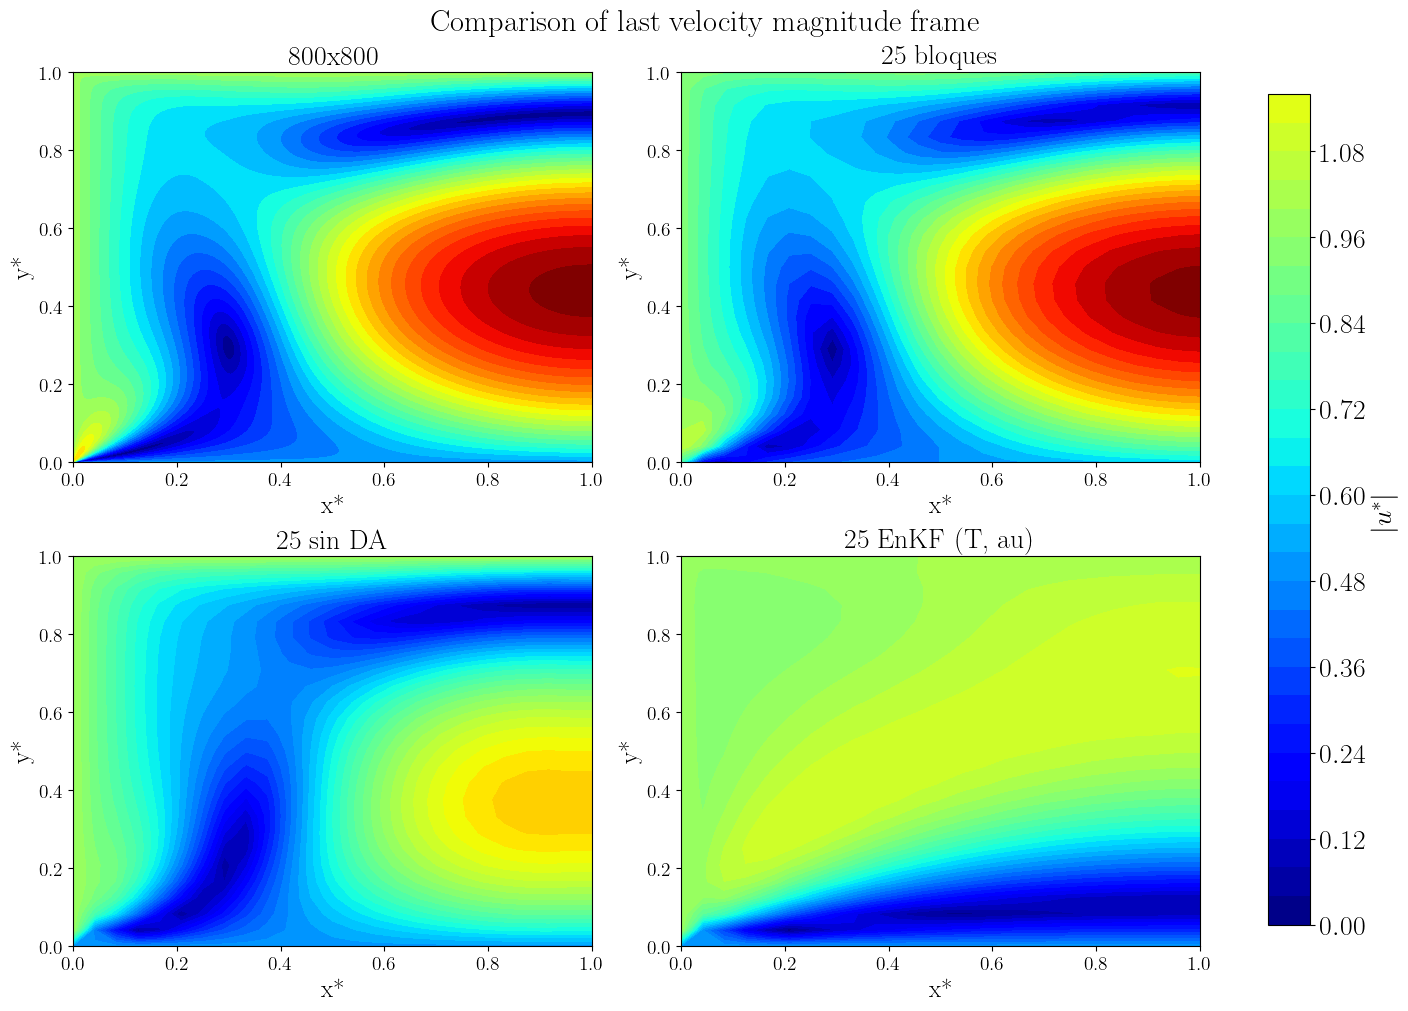

In [33]:
# === 1. Definir rutas de los archivos ===
archivos = {
    "800x800": "sim_normal/800.pkl",
    "25 bloques": "sim_normal/25_bloques.pkl",
    "25 sin DA": "sim_normal/25.pkl",
    "25 EnKF (T,\tau)": "DA_grid_obs/enkf_grid_obs_st.pkl"
}

vel_magnitudes = {}
grillas = {}

# === 2. Calcular magnitudes y guardar ===
for nombre, ruta in archivos.items():
    with open(ruta, "rb") as f:
        sim = pickle.load(f)
        u = np.array(sim["u_history"][-1])
        v = np.array(sim["v_history"][-1])
        vel_mag = np.sqrt(u**2 + v**2)
        vel_magnitudes[nombre] = vel_mag
        grillas[nombre] = (sim["X_star"], sim["Y_star"])

# === 3. Calcular límites globales para la escala ===
vmin = min(np.min(v) for v in vel_magnitudes.values())
vmax = max(np.max(v) for v in vel_magnitudes.values())

# === 4. Crear subplots ===
fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axs = axs.flatten()

for ax, (nombre, vel_mag) in zip(axs, vel_magnitudes.items()):
    X, Y = grillas[nombre]
    cf = ax.contourf(X, Y, vel_mag, levels=30, cmap="jet", vmin=vmin, vmax=vmax)
    ax.set_title(nombre, fontsize=20)
    ax.set_xlabel("x*", fontsize=18)
    ax.set_ylabel("y*", fontsize=18)
    ax.tick_params(labelsize=14)

# === 5. Colorbar global ===
cbar = fig.colorbar(cf, ax=axs.ravel().tolist(), shrink=0.95)
cbar.set_label(r" $|u^*|$", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.suptitle("Comparison of last velocity magnitude frame", fontsize=22)
plt.show()
